# SFR Fly Mean-Reversion — 3. Cointegration

**Formulation: is `1/-2/1` actually the cointegrating vector?**

A butterfly asserts weights `(-1, +2, -1)` on the three legs' rates. That is a
convention, not an estimate. This notebook estimates the vector instead — by
Engle-Granger (regress the belly on its two wings), by Johansen, and by
Box-Tiao (the linear combination with the *slowest* variance ratio, i.e. the
most mean-reverting portfolio) — and trades both the asserted and the fitted
spread.

If the fitted vector is far from `(0.5, 0.5)` on the wings, the traded fly is
not the stationary combination and its "mean reversion" is partly a trend in
whatever the fly is loading on that the fitted vector hedges out. If the fitted
vector trades no better than the asserted one, the convention is fine and the
extra estimation is noise.

Box-Tiao and Johansen come from `arbitragelab`, which is installed editable in
this environment (mapped to `RVUtils/arbitragelab`), so they are the reference
implementations rather than re-derivations.

In [1]:
CONFIG = dict(
    primary_structure="3m",
    primary_window="liquid16",
    long_window="front8",
    cost_bp=1.5,
    n_packages=100,
    coint_windows=(252, 500),      # rolling estimation window for the vector
    z_windows=(60, 120),
    entry_zs=(1.5, 2.0, 2.5),
    exits=("z0", "half", "t10"),
    directions=("fade", "momentum"),
    max_hold=30,
    lag=1,
    refit_every=21,                # Johansen / Box-Tiao refit cadence
)
CONFIG

{'primary_structure': '3m',
 'primary_window': 'liquid16',
 'long_window': 'front8',
 'cost_bp': 1.5,
 'n_packages': 100,
 'coint_windows': (252, 500),
 'z_windows': (60, 120),
 'entry_zs': (1.5, 2.0, 2.5),
 'exits': ('z0', 'half', 't10'),
 'directions': ('fade', 'momentum'),
 'max_hold': 30,
 'lag': 1,
 'refit_every': 21}

In [2]:
import sys
from pathlib import Path

sys.path.append("../../")
sys.path.append(str(Path.cwd()))

import dataclasses

import numpy as np
import pandas as pd

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from RVUtils.MeanRev import MRConfig, run_backtest
from RVUtils.MeanRev.signals import coint_spread_signal, zscore_signal
from RVUtils.cointegration import engle_granger, johansen
from RVUtils.mean_reversion import adf_pvalue, half_life, rolling_zscore
from sfr_fly_meanrev_common import (
    header_block, league_row, load_lab, per_slot_table, regime_block, run_family,
    shadow_block, three_panel_equity,
)

pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 60)

BASE = MRConfig(lag=CONFIG["lag"], round_trip_cost_bp=CONFIG["cost_bp"],
                max_hold=CONFIG["max_hold"], n_packages=CONFIG["n_packages"])
lab = load_lab(CONFIG["primary_structure"], CONFIG["primary_window"])
st, levels = lab["struct"], lab["levels"]
print(f"{levels.shape[1]} flies, {levels.shape[0]} sessions")

34 flies, 1150 sessions


## 1. Full-sample Engle-Granger and Johansen per fly

`beta_front + beta_back` near 1.0 with each near 0.5 is the butterfly. The
Johansen vector is normalised so the belly weight is 1, then rescaled the same
way, so the two are directly comparable to `(0.5, 0.5)`.

In [3]:
rows = []
for key, g in st.groupby("key"):
    g = g.sort_values("as_of")
    if len(g) < 300:
        continue
    idx = pd.DatetimeIndex(g["as_of"])
    f = pd.Series(g["leg0_value"].to_numpy(float), index=idx)
    b = pd.Series(g["leg1_value"].to_numpy(float), index=idx)
    k = pd.Series(g["leg2_value"].to_numpy(float), index=idx)
    X = pd.DataFrame({"f": f, "k": k})
    eg_f = engle_granger(b, f)
    eg_k = engle_granger(b, k)
    # two-regressor EG: belly on both wings
    import statsmodels.api as sm
    A = sm.add_constant(X.values)
    fit = sm.OLS(b.values, A).fit()
    resid = pd.Series(b.values - A @ fit.params, index=idx)
    asserted = pd.Series((2 * b - f - k).to_numpy(), index=idx)
    try:
        joh = johansen(pd.DataFrame({"b": b, "f": f, "k": k}))
        jv = joh["coint_vector"]
        jv = jv / jv[0] if abs(jv[0]) > 1e-9 else jv
        j_f, j_k, j_rank = -jv[1], -jv[2], joh["rank"]
    except Exception:
        j_f = j_k = np.nan
        j_rank = -1
    rows.append({
        "key": key, "n": len(g),
        "eg_b_front": fit.params[1], "eg_b_back": fit.params[2],
        "eg_sum": fit.params[1] + fit.params[2],
        "joh_front": j_f, "joh_back": j_k, "joh_rank": j_rank,
        "adf_fitted": adf_pvalue(resid), "adf_asserted": adf_pvalue(asserted),
        "hl_fitted": half_life(resid * 100), "hl_asserted": half_life(asserted * 100),
    })
vec = pd.DataFrame(rows)
print(vec.round(3).to_string(index=False))
print("\nsummary (the butterfly convention is beta_front = beta_back = 0.5):")
print(vec[["eg_b_front", "eg_b_back", "eg_sum", "joh_front", "joh_back",
           "adf_fitted", "adf_asserted", "hl_fitted", "hl_asserted"]]
      .describe().round(3).to_string())
print(f"\nfitted spread stationary at 10%: "
      f"{int((vec['adf_fitted'] < 0.10).sum())}/{len(vec)} keys")
print(f"asserted fly stationary at 10%:   "
      f"{int((vec['adf_asserted'] < 0.10).sum())}/{len(vec)} keys")

        key   n  eg_b_front  eg_b_back  eg_sum  joh_front  joh_back  joh_rank  adf_fitted  adf_asserted  hl_fitted  hl_asserted
H23-M23-U23 300       0.363      0.668   1.031      0.280     0.758         1       0.066         0.434      6.164       13.916
H24-M24-U24 556       0.410      0.625   1.035      0.402     0.637         1       0.044         0.239     20.362       42.026
H25-M25-U25 806       0.388      0.620   1.008     -0.025     1.168         1       0.485         0.210     27.405       43.043
H26-M26-U26 876       0.436      0.570   1.006      0.424     0.585         2       0.985         0.458     28.198       47.002
H27-M27-U27 718       0.560      0.450   1.010      0.628     0.380         3       0.199         0.854     11.154       23.052
H28-M28-U28 468       0.430      0.574   1.004      0.434     0.571         2       0.001         0.583      1.126        3.143
M23-U23-Z23 368       0.445      0.586   1.032      0.622     0.373         3       0.129         0.393 

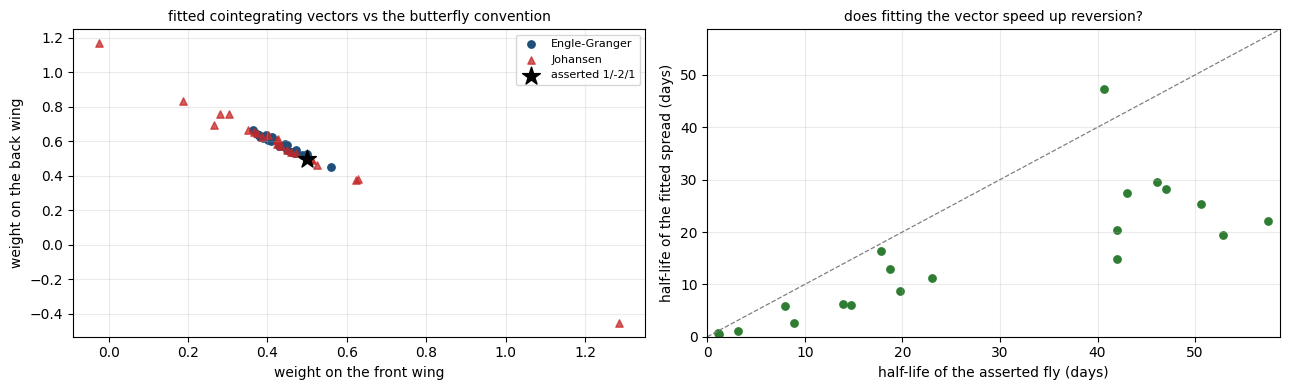

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(vec["eg_b_front"], vec["eg_b_back"], s=28, color="#1f4e79",
                label="Engle-Granger")
axes[0].scatter(vec["joh_front"], vec["joh_back"], s=28, color="#c62828",
                marker="^", alpha=0.75, label="Johansen")
axes[0].scatter([0.5], [0.5], s=180, marker="*", color="black",
                label="asserted 1/-2/1", zorder=5)
axes[0].set_xlabel("weight on the front wing")
axes[0].set_ylabel("weight on the back wing")
axes[0].set_title("fitted cointegrating vectors vs the butterfly convention",
                  fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)
axes[1].scatter(vec["hl_asserted"], vec["hl_fitted"], s=28, color="#2e7d32")
lim = np.nanpercentile(np.concatenate([vec["hl_asserted"].to_numpy(),
                                       vec["hl_fitted"].to_numpy()]), 95)
axes[1].plot([0, lim], [0, lim], color="grey", lw=0.9, ls="--")
axes[1].set_xlim(0, lim)
axes[1].set_ylim(0, lim)
axes[1].set_xlabel("half-life of the asserted fly (days)")
axes[1].set_ylabel("half-life of the fitted spread (days)")
axes[1].set_title("does fitting the vector speed up reversion?", fontsize=10)
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 2. Box-Tiao — the most mean-reverting combination

Box-Tiao finds the linear combination of the three legs with the smallest
predictable-to-total variance ratio, i.e. the *fastest* reverting portfolio
available from these legs. It is the strongest possible statement of "if any
combination of these three contracts mean-reverts, it is this one" — so if
Box-Tiao's own portfolio does not survive costs, no weighting of the legs will.

In [5]:
try:
    from arbitragelab.hedge_ratios import get_box_tiao_hedge_ratio
    HAVE_BT = True
except Exception as exc:
    print(f"arbitragelab Box-Tiao unavailable: {type(exc).__name__}: {exc}")
    HAVE_BT = False

bt_rows = []
if HAVE_BT:
    for key, g in st.groupby("key"):
        g = g.sort_values("as_of")
        if len(g) < 300:
            continue
        idx = pd.DatetimeIndex(g["as_of"])
        df = pd.DataFrame({"b": g["leg1_value"].to_numpy(float),
                           "f": g["leg0_value"].to_numpy(float),
                           "k": g["leg2_value"].to_numpy(float)}, index=idx)
        try:
            hedge, _, _, resid = get_box_tiao_hedge_ratio(df, dependent_variable="b")
        except Exception:
            continue
        w = {kk: float(v) for kk, v in hedge.items()}
        s = pd.Series(resid, index=idx) * 100
        bt_rows.append({"key": key, "w_b": w.get("b", np.nan),
                        "w_front": -w.get("f", np.nan), "w_back": -w.get("k", np.nan),
                        "hl": half_life(s), "adf": adf_pvalue(s), "sd_bp": s.std()})
if bt_rows:
    bt = pd.DataFrame(bt_rows)
    print(bt.round(3).to_string(index=False))
    print("\nBox-Tiao weights vs the butterfly's (0.5, 0.5) on the wings:")
    print(bt[["w_front", "w_back", "hl", "adf", "sd_bp"]].describe().round(3).to_string())
    print(f"\nBox-Tiao spread half-life median {bt['hl'].median():.1f}d vs "
          f"asserted fly {vec['hl_asserted'].median():.1f}d")
else:
    bt = pd.DataFrame()
    print("no Box-Tiao rows")

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe

        key  w_b  w_front  w_back     hl   adf  sd_bp
H23-M23-U23  1.0   -0.359  -0.672  6.158 0.060  2.151
H24-M24-U24  1.0   -0.370  -0.679 17.812 0.034  2.252
H25-M25-U25  1.0   -0.308  -0.720 25.752 0.033  1.758
H26-M26-U26  1.0   -0.431  -0.569 28.128 0.974  1.129
H27-M27-U27  1.0   -0.583  -0.429 10.702 0.090  0.745
H28-M28-U28  1.0   -0.428  -0.577  1.124 0.000  0.216
M23-U23-Z23  1.0   -0.445  -0.586 12.947 0.129  2.894
M24-U24-Z24  1.0   -0.305  -0.754 17.209 0.006  2.669
M25-U25-Z25  1.0   -0.612  -0.346 25.061 0.002  2.653
M26-U26-Z26  1.0   -0.343  -0.652 20.424 0.021  1.177
M27-U27-Z27  1.0   -0.490  -0.520  5.866 0.047  0.468
M28-U28-Z28  1.0   -0.469  -0.532  0.675 0.000  0.173
U23-Z23-H24  1.0   -0.496  -0.538 22.078 0.038  2.611
U24-Z24-H25  1.0   -0.442  -0.565 28.739 0.086  1.845
U25-Z25-H26  1.0   -0.451  -0.545  8.652 0.040  0.835
U26-Z26-H27  1.0   -0.347  -0.667 10.187 0.000  0.854
U27-Z27-H28  1.0   -0.399  -0.615  6.020 0.016  0.498
U28-Z28-H29  1.0   -0.461  -

C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\chris\anaconda3\envs\stir\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored whe

## 3. Backtest — the ASSERTED fly, z-scored (the benchmark)


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/36 configs


  36 configs | median -556.75bp | IQR [-801.25, -373.00] | 0% net-positive | best -113.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    120      2.5       half      fade       174     0.241      -0.652       -113.50      -283750.0  -0.580    -163.25
    120      2.5         z0      fade       168     0.232      -0.878       -147.50      -368750.0  -0.718    -180.50
    120      2.5        t10      fade       224     0.147      -0.973       -218.00      -545000.0  -1.467    -240.50
     60      2.5       half      fade       216     0.222      -1.223       -264.25      -660625.0  -1.243    -279.75
     60      2.5        t10      fade       253     0.166      -1.177       -297.75      -744375.0  -1.844    -300.75
     60      2.5         z0      fade       215     0.181      -1.397       -300.25      -750625.0  -1.291    -312.75
     60     

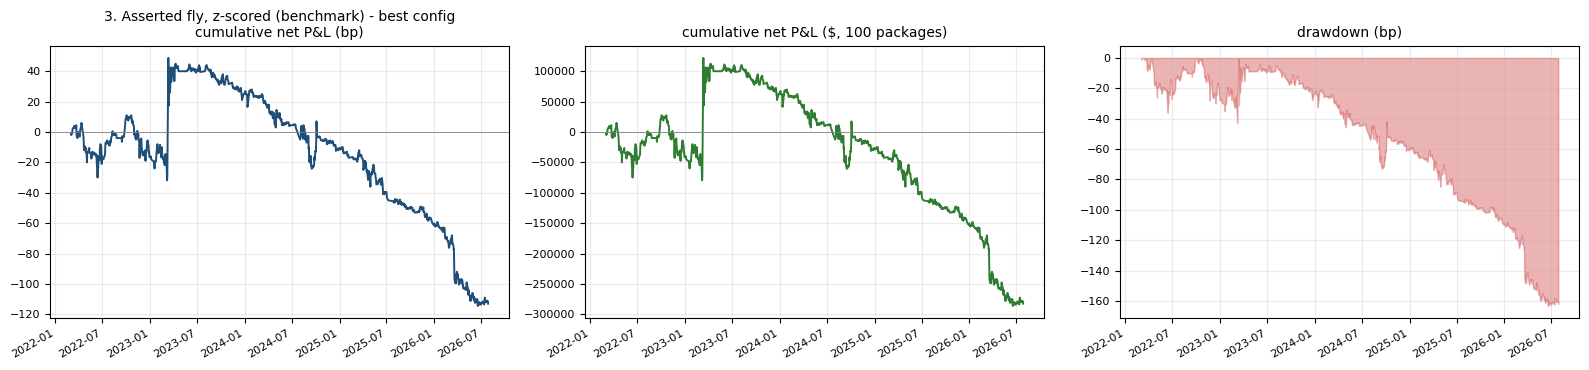


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
Z23-H24-M24    1  2022-03-01 2022-03-02 2022-03-22    14 -3.517     -2.00      -1.00       1.0      1.5    -0.5  -1250.0 take_profit
U23-Z23-H24   -1  2022-03-01 2022-03-02 2022-03-11     7  3.215      6.50       4.50       2.0      1.5     0.5   1250.0 take_profit
Z24-H25-M25    1  2022-03-04 2022-03-07 2022-03-16     7 -2.624     -3.00      -1.50       1.5      1.5     0.0      0.0 take_profit
H24-M24-U24    1  2022-03-04 2022-03-07 2022-03-31    18 -3.062     -5.50      -2.00       3.5      1.5     2.0   5000.0 take_profit
M23-U23-Z23   -1  2022-03-15 2022-03-16 2022-03-24     6  2.961      6.50       4.00       2.5      1.5     1.0   2500.0 take_profit
H25-M25-U25    1  2022-03-17 2022-03-18 2022-04-04    11 -2.942     -2.50      -1.50       1.0      1.5    -0.5  -1250.0 take_profit
Z22-H23-M23   -1  2022-03-21 2022-03-22 20

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       168    21.929     0.232      -0.878        -147.5  -0.718
half       174    19.259     0.241      -0.652        -113.5  -0.580
band       174    19.259     0.241      -0.652        -113.5  -0.580
  t5       285     4.982     0.133      -1.098        -313.0  -2.583
 t10       224     9.911     0.147      -0.973        -218.0  -1.467
 t20       176    19.807     0.188      -0.906        -159.5  -1.084

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 174         147.5       0.848     0.523       368750.0
           0.5 174          60.5       0.348     0.379       151250.0
           1.0 174         -26.5      -0.152     0.299       -66250.0
           1.5 174        -113.5      -0.652     0.241      -283750.0
           2.5 174        -287.5      -1.652     0.167      -718750.0
           4.0 174        -548.5      -3.15


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5       174           147.5        -113.5      -0.652     0.241  -0.580     -163.3      19.3          False             False
         belly       1            0.5       174           618.5         531.5       3.055     0.489   0.498     -344.5      19.3           True              True
belly_vs_front       2            1.0       174           -43.5        -217.5      -1.250     0.259  -0.764     -277.7      19.3          False             False
 belly_vs_back       2            1.0       174           191.0          17.0       0.098     0.391   0.097      -81.5      19.3           True              True
  -> SHADOWED - a simpler instrument beats the fly on net bp
3. Asserted fly, z-scored (benchmark) - MEDIAN config (t

In [6]:
GRID_A = {"window": CONFIG["z_windows"], "entry_z": CONFIG["entry_zs"],
          "exit_style": CONFIG["exits"], "direction": CONFIG["directions"]}
PARAMS_A = ["window", "entry_z", "exit_style", "direction"]
out_a = run_family("3. Asserted fly, z-scored (benchmark)", lab=lab,
                   signal_fn=lambda L, window: zscore_signal(L, window=window),
                   grid_spec=GRID_A, params=PARAMS_A, base=BASE, cls="coint",
                   note="the 1/-2/1 convention, standardised")

## 4. Backtest — the FITTED (rolling Engle-Granger) spread

Important: the P&L is still marked on the **traded** fly, because a fitted
vector with non-integer weights is not what gets executed. The fitted spread
supplies the *signal*; the butterfly remains the instrument. Trading the fitted
weights themselves would need per-leg contract counts and a different cost
model, and is out of scope here.


### GRID  (34 keys, 1150 sessions, window=liquid16: every strip slot trades every session from 2022)


  25/72 configs


  50/72 configs


  72 configs | median -188.00bp | IQR [-319.88, -119.12] | 0% net-positive | best -7.50bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 coint_window  z_window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
          500       120      2.5         z0  momentum        42     0.381      -0.179         -7.50       -18750.0  -0.130     -44.75
          500       120      2.5       half  momentum        43     0.349      -0.262        -11.25       -28125.0  -0.200     -44.75
          500        60      2.5       half  momentum        53     0.283      -0.660        -35.00       -87500.0  -0.666     -61.75
          500        60      2.5         z0  momentum        53     0.302      -0.750        -39.75       -99375.0  -0.748     -66.50
          500       120      2.5        t10  momentum        59     0.169      -1.284        -75.75      -189375.0  -2.046     -86.25
          500       120      2.0    

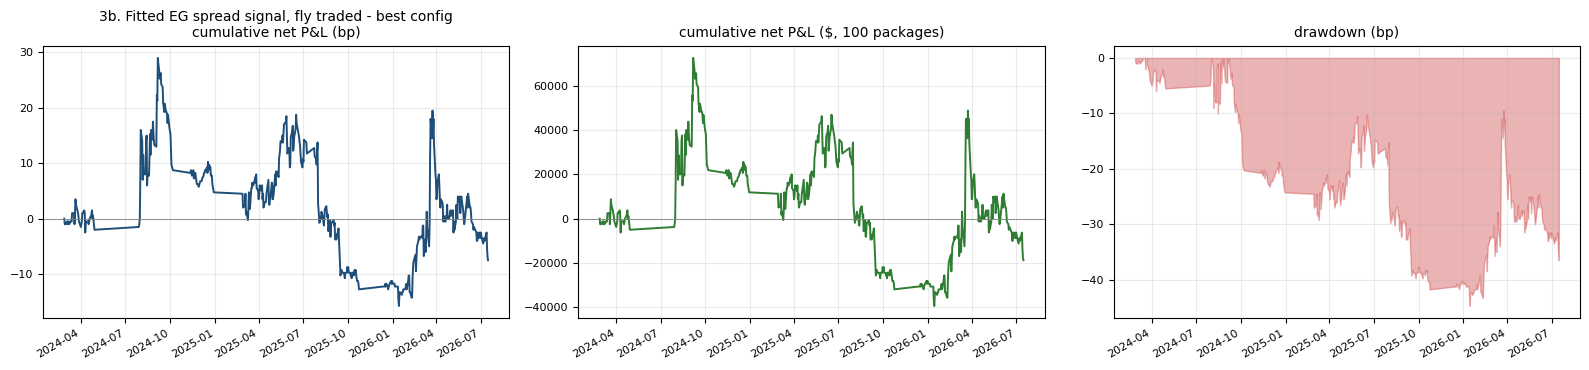


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd    exit_reason
M25-U25-Z25    1  2024-02-23 2024-02-26 2024-04-09    30  2.507      -6.5      -4.00      2.50      1.5    1.00   2500.0       max_hold
M24-U24-Z24   -1  2024-03-14 2024-03-15 2024-04-29    30 -2.888       1.5       3.00     -1.50      1.5   -3.00  -7500.0       max_hold
Z24-H25-M25   -1  2024-07-24 2024-07-25 2024-09-06    30 -2.511      -9.0     -29.00     20.00      1.5   18.50  46250.0       max_hold
H25-M25-U25   -1  2024-07-24 2024-07-25 2024-09-06    30 -2.660      -9.0     -18.00      9.00      1.5    7.50  18750.0       max_hold
U24-Z24-H25   -1  2024-08-02 2024-08-05 2024-09-10    25 -2.797     -15.5     -17.25      1.75      1.5    0.25    625.0 mean_reversion
M25-U25-Z25   -1  2024-08-08 2024-08-09 2024-09-23    30 -2.588      -7.5      -9.00      1.50      1.5   -0.00     -0.0       max_hold
Z25-H26-M26   -1  202


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5        42            55.5          -7.5      -0.179     0.381  -0.130      -44.8      23.6          False             False
         belly       1            0.5        42           401.0         380.0       9.048     0.571   0.918     -163.0      23.6           True              True
belly_vs_front       2            1.0        42           122.0          80.0       1.905     0.524   0.983      -37.0      23.6           True              True
 belly_vs_back       2            1.0        42           -66.5        -108.5      -2.583     0.310  -1.985     -129.5      23.6          False             False
  -> SHADOWED - a simpler instrument beats the fly on net bp


3b. Fitted EG spread signal, fly traded - MEDIAN config (the anti-selection control)  |  momentum|z2.5|half|hold30|lag1|every1|c1.5  |  100 packages ($2,500/bp, 400 contracts)
  trades   135   skipped    0   hit 16%   avg -1.407bp   avg hold 13.3d
  total    -190.00bp   $     -475,000   gross +12.50bp
  daily-MTM Sharpe -1.93   maxDD -198.00bp ($-495,000)   worst trade -12.00bp
  t(trade) -5.02   NW t(daily) -3.63   non-overlap SR -0.66   DSR p=0.000 over 72 trials

  LEAGUE ROW  3b. Fitted EG spread signal, fly traded / best-config: MARGINAL-maker-only  (taker -49.50bp, maker +55.50bp, DSR p=0.001)

  LEAGUE ROW  3b. Fitted EG spread signal, fly traded / median-config: MARGINAL-maker-only  (taker -325.00bp, maker +12.50bp, DSR p=0.000)


In [7]:
def coint_sig(L, coint_window, z_window):
    return coint_spread_signal(st, window=coint_window, z_window=z_window)["signal"] \
        .reindex(index=L.index, columns=L.columns)


GRID_B = {"coint_window": CONFIG["coint_windows"], "z_window": CONFIG["z_windows"],
          "entry_z": CONFIG["entry_zs"], "exit_style": CONFIG["exits"],
          "direction": CONFIG["directions"]}
PARAMS_B = ["coint_window", "z_window", "entry_z", "exit_style", "direction"]
out_b = run_family("3b. Fitted EG spread signal, fly traded", lab=lab,
                   signal_fn=coint_sig, grid_spec=GRID_B, params=PARAMS_B,
                   base=BASE, cls="coint",
                   note="rolling belly-on-wings residual as the signal")

## 5. Head to head

The comparison that matters: does estimating the vector beat asserting it?

In [8]:
cmp = pd.DataFrame([
    {"variant": "asserted 1/-2/1 z-score",
     "median_net_bp": out_a["grid"]["total_net_bp"].median(),
     "best_net_bp": out_a["grid"]["total_net_bp"].max(),
     "pct_positive": (out_a["grid"]["total_net_bp"] > 0).mean(),
     "best_sharpe": out_a["grid"]["sharpe"].max()},
    {"variant": "fitted EG residual z-score",
     "median_net_bp": out_b["grid"]["total_net_bp"].median(),
     "best_net_bp": out_b["grid"]["total_net_bp"].max(),
     "pct_positive": (out_b["grid"]["total_net_bp"] > 0).mean(),
     "best_sharpe": out_b["grid"]["sharpe"].max()},
])
print(cmp.round(3).to_string(index=False))

                   variant  median_net_bp  best_net_bp  pct_positive  best_sharpe
   asserted 1/-2/1 z-score        -556.75       -113.5           0.0        -0.58
fitted EG residual z-score        -188.00         -7.5           0.0        -0.13


## 6. Long window


### GRID  (42 keys, 1907 sessions, window=front8: slots 1-8 are continuously liquid from 2019; buys ZIRP+hiking)


  25/36 configs


  36 configs | median -407.62bp | IQR [-530.50, -274.38] | 0% net-positive | best -92.75bp

  top rows (SELECTION-INFLATED - read the distribution above first):
 window  entry_z exit_style direction  n_trades  hit_rate  avg_net_bp  total_net_bp  total_net_usd  sharpe  max_dd_bp
    120      2.5       half      fade       136     0.346      -0.682        -92.75      -231875.0  -0.442    -128.75
    120      2.5         z0      fade       134     0.358      -0.897       -120.25      -300625.0  -0.540    -140.25
    120      2.5        t10      fade       195     0.246      -0.917       -178.75      -446875.0  -1.106    -184.25
     60      2.5       half      fade       170     0.265      -1.344       -228.50      -571250.0  -1.017    -237.00
     60      2.5        t10      fade       205     0.259      -1.122       -230.00      -575000.0  -1.340    -233.00
     60      2.5         z0  momentum       165     0.315      -1.467       -242.00      -605000.0  -0.993    -246.50
    120      

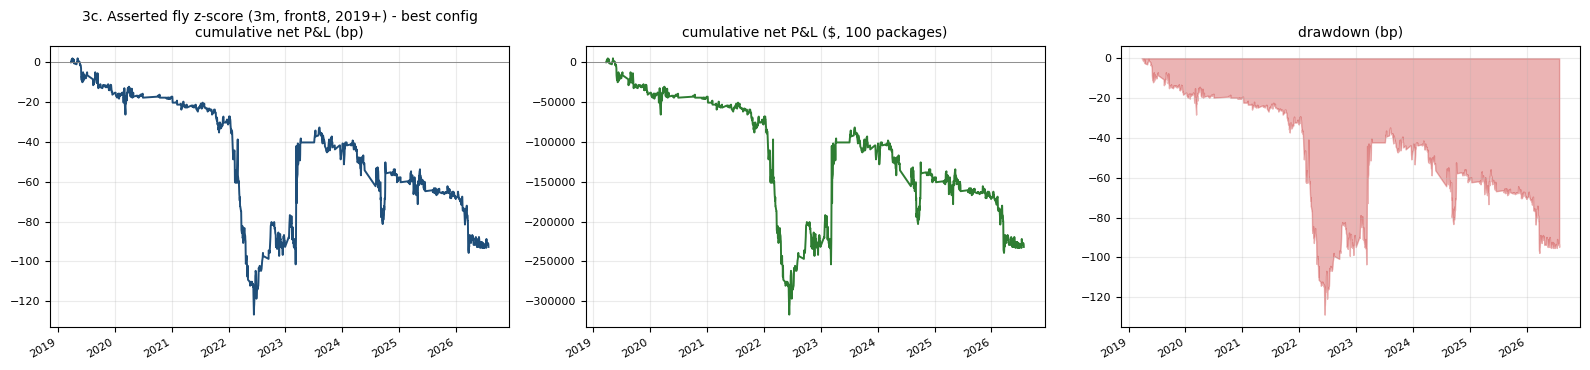


  trade log (first rows):
        key  dir signal_date      entry       exit  days   z_in  level_in  level_out  gross_bp  cost_bp  net_bp  net_usd exit_reason
M20-U20-Z20    1  2019-03-25 2019-03-26 2019-04-10    11 -3.409      -3.0      -2.50      0.50      1.5   -1.00  -2500.0 take_profit
M19-U19-Z19    1  2019-03-25 2019-03-26 2019-04-08     9 -4.217       0.5       2.50      2.00      1.5    0.50   1250.0 take_profit
H20-M20-U20    1  2019-03-27 2019-03-28 2019-04-02     3 -2.934      -3.0      -1.50      1.50      1.5   -0.00     -0.0 take_profit
U19-Z19-H20    1  2019-03-28 2019-03-29 2019-04-15    11 -2.501      -0.5       1.00      1.50      1.5   -0.00     -0.0 take_profit
M19-U19-Z19    1  2019-04-29 2019-04-30 2019-05-09     7 -2.558      -0.5       2.50      3.00      1.5    1.50   3750.0 take_profit
U19-Z19-H20    1  2019-05-13 2019-05-14 2019-06-26    30 -3.232      -1.5      -3.00     -1.50      1.5   -3.00  -7500.0    max_hold
H20-M20-U20    1  2019-05-15 2019-05-16 20

exit  n_trades  avg_hold  hit_rate  avg_net_bp  total_net_bp  sharpe
  z0       134    23.239     0.358      -0.897       -120.25  -0.540
half       136    20.882     0.346      -0.682        -92.75  -0.442
band       136    20.882     0.346      -0.682        -92.75  -0.442
  t5       259     4.946     0.208      -1.099       -284.75  -2.217
 t10       195     9.821     0.246      -0.917       -178.75  -1.106
 t20       145    19.600     0.241      -0.981       -142.25  -0.816

  cost curve (round-trip bp charged on the package):
 round_trip_bp   n  total_net_bp  avg_net_bp  hit_rate  total_net_usd
           0.0 136        111.25       0.818     0.581       278125.0
           0.5 136         43.25       0.318     0.515       108125.0
           1.0 136        -24.75      -0.182     0.449       -61875.0
           1.5 136        -92.75      -0.682     0.346      -231875.0
           2.5 136       -228.75      -1.682     0.221      -571875.0
           4.0 136       -432.75      -3.18


LINEAR-SHADOW DECOMPOSITION (same signal, simpler instrument, own cost)
    instrument  n_legs  round_trip_bp  n_trades  total_gross_bp  total_net_bp  avg_net_bp  hit_rate  sharpe  max_dd_bp  avg_hold  beats_fly_net  beats_fly_sharpe
           fly       3            1.5       136           111.2         -92.8      -0.682     0.346  -0.442     -128.7      20.9          False             False
         belly       1            0.5       136          -349.5        -417.5      -3.070     0.478  -0.306     -895.5      20.9          False              True
belly_vs_front       2            1.0       136           -82.2        -218.2      -1.605     0.353  -0.768     -256.5      20.9          False             False
 belly_vs_back       2            1.0       136           193.5          57.5       0.423     0.463   0.297      -87.0      20.9           True              True
  -> SHADOWED - a simpler instrument beats the fly on net bp
3c. Asserted fly z-score (3m, front8, 2019+) - MEDIAN co

In [9]:
lab8 = load_lab(CONFIG["primary_structure"], CONFIG["long_window"])
out8 = run_family("3c. Asserted fly z-score (3m, front8, 2019+)", lab=lab8,
                  signal_fn=lambda L, window: zscore_signal(L, window=window),
                  grid_spec=GRID_A, params=PARAMS_A, base=BASE, cls="coint",
                  note="long history")